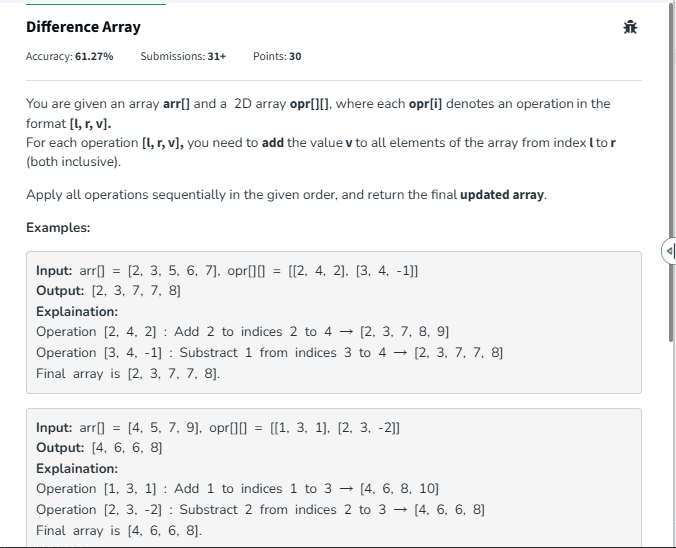
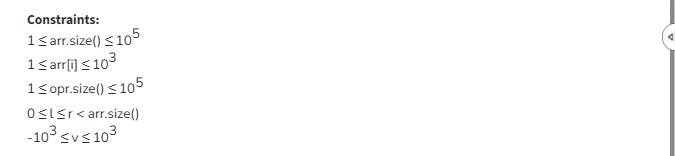

Input:

arr = [2, 3, 5, 6, 7]
opr = [[2, 4, 2], [3, 4, -1]]


Step 1: Initialize Difference Array
k = 5, n = 2
pref = [0, 0, 0, 0, 0]

Step 2: Apply Operations to pref (Difference Array)

| Operation Index | `l` | `r` | `v` | Action                        | `pref` After Operation         |
|-----------------|-----|-----|-----|-------------------------------|--------------------------------|
| 0               | 2   | 4   | 2   | `pref[2] += 2`                | `[0, 0, 2, 0, 0]`              |
|                 |     |     |     | `r+1 = 5` → out of bounds     | (no change)                    |
| 1               | 3   | 4   | -1  | `pref[3] += -1`               | `[0, 0, 2, -1, 0]`             |
|                 |     |     |     | `r+1 = 5` → out of bounds     | (no change)                    |

Final pref (before prefix sum): [0, 0, 2, -1, 0]

Step 3: Compute Prefix Sum of pref

| Index `i` | `pref[i]` (before) | `pref[i-1]` | `pref[i] = pref[i-1] + pref[i]` | `pref` (after)        |
|-----------|---------------------|--------------|----------------------------------|------------------------|
| 0         | 0                   | -            | (unchanged)                      | `[0, 0, 2, -1, 0]`     |
| 1         | 0                   | 0            | 0 + 0 = 0                        | `[0, 0, 2, -1, 0]`     |
| 2         | 2                   | 0            | 0 + 2 = 2                        | `[0, 0, 2, -1, 0]`     |
| 3         | -1                  | 2            | 2 + (-1) = 1                     | `[0, 0, 2, 1, 0]`      |
| 4         | 0                   | 1            | 1 + 0 = 1                        | `[0, 0, 2, 1, 1]`      |

Final pref (total changes): [0, 0, 2, 1, 1]

Step 4: Add Changes to Original arr

| Index | `arr[i]` (original) | `pref[i]` (change) | `arr[i] + pref[i]` | Final `arr`        |
|-------|----------------------|---------------------|---------------------|---------------------|
| 0     | 2                    | 0                   | 2                   | `[2, ...`           |
| 1     | 3                    | 0                   | 3                   | `[2, 3, ...`        |
| 2     | 5                    | 2                   | 7                   | `[2, 3, 7, ...`     |
| 3     | 6                    | 1                   | 7                   | `[2, 3, 7, 7, ...`  |
| 4     | 7                    | 1                   | 8                   | `[2, 3, 7, 7, 8]`   |

✅ Final Output:

[2, 3, 7, 7, 8]

In [ ]:
class Solution:
    def diffArray(self, arr, opr):
        # code here
        
        k = len(arr)
        
        n = len(opr)

        pref = [0] * k

        for i in range(n):
            
            l = opr[i][0]
            r = opr[i][1]
            v = opr[i][2]
            
            pref[l] += v
            if r + 1 < k:
                pref[r + 1] -= v 

        for i in range(1, k):
            pref[i] = pref[i - 1] + pref[i]
            
        arr = list(map(lambda x, y : x + y, pref, arr))
            
        return arr
        

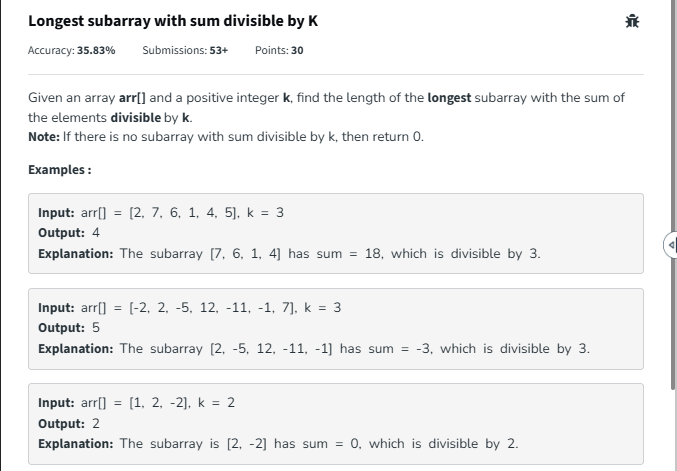
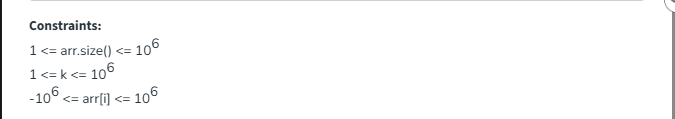

| Index (i) | Value | Prefix Sum | Remainder (`sum % 3`) | Map State `{rem: index}` | Action | Max Len |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| - | - | 0 | 0 | `{0: -1}` | Init | 0 |
| 0 | 2 | 2 | 2 | `{0: -1, 2: 0}` | Store 2 | 0 |
| 1 | 7 | 9 | 0 | `{0: -1, 2: 0}` | Found 0. Len = `1 - (-1)` = 2 | 2 |
| 2 | 6 | 15 | 0 | `{0: -1, 2: 0}` | Found 0. Len = `2 - (-1)` = 3 | 3 |
| 3 | 1 | 16 | 1 | `{..., 1: 3}` | Store 1 | 3 |
| 4 | 4 | 20 | 2 | `{..., 2: 0}` | Found 2. Len = `4 - 0` = 4 | 4 |
| 5 | 5 | 25 | 1 | `{..., 1: 3}` | Found 1. Len = `5 - 3` = 2 | 4 |

In [ ]:

class Solution:
	def longestSubarrayDivK(self, arr, k):
		#Complete the function

        n = len(arr)
        
        pref = 0
        
        first_occurance = {0 : -1}
        
        max_sublen = 0
        
        for i in range(n):
            curr_len = 0
            
            pref += arr[i]
            
            rem = pref % k
            
            if rem < 0:
                rem += k
                
            if rem in first_occurance:
                curr_len = i - first_occurance[rem]
                
                max_sublen = max(max_sublen, curr_len)
            else:
                first_occurance[rem] = i
                
        return max_sublen
                
            

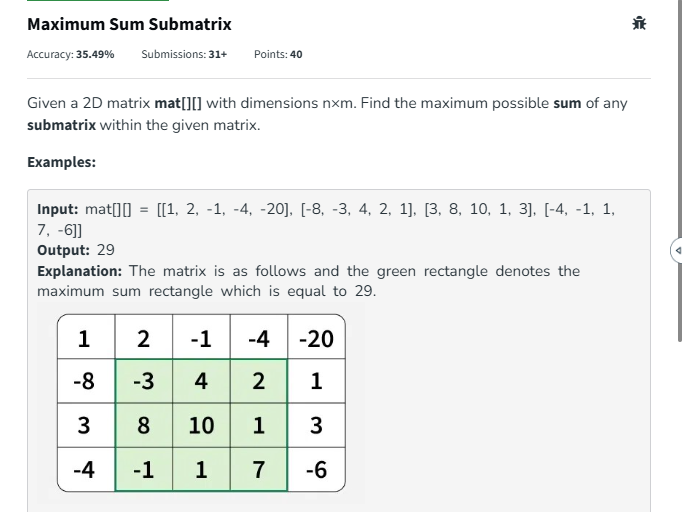
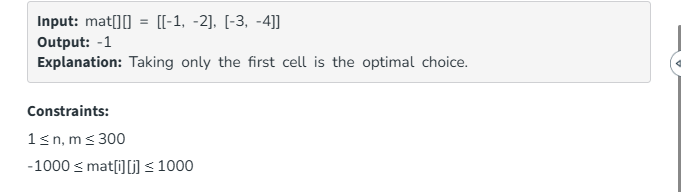

In [ ]:
# Brute Force - compute all the sums TC : O(n²m²) ~ 300 ^ 4 = 81 x 10^8 -> TLE

class Solution:

    def maxRectSum(self, mat):

        n = len(mat)
        m = len(mat[0])

        pref = [[0] * m for _ in range(n)]

        # Build Prefix Sum Matrix
        for i in range(n):
            for j in range(m):

                pref[i][j] = mat[i][j]

                if i > 0:
                    pref[i][j] += pref[i-1][j]

                if j > 0:
                    pref[i][j] += pref[i][j-1]

                if i > 0 and j > 0:
                    pref[i][j] -= pref[i-1][j-1]

        maxSum = float('-inf')

        # Enumerate all rectangles
        for x1 in range(n):

            for y1 in range(m):

                for x2 in range(x1, n):

                    for y2 in range(y1, m):

                        curr = pref[x2][y2]

                        if x1 > 0:
                            curr -= pref[x1-1][y2]

                        if y1 > 0:
                            curr -= pref[x2][y1-1]

                        if x1 > 0 and y1 > 0:
                            curr += pref[x1-1][y1-1]

                        maxSum = max(maxSum, curr)

        return maxSum

mat = [
  [1, 2, -1],

        [-3, 4, 2],

        [5, -2, 3]
]   

| Step | `left` | `right` | **Active Submatrix Columns** | **`temp` Calculation** <br>(Row Sums) | `temp` Array | **Kadane Analysis** <br>(Best Row Range) | **Submatrix Identified** <br>(Rows $\times$ Cols) | **Sum** | Global `ans` |
|:----:|:------:|:-------:|:----------------------------:|:-------------------------------------:|:------------:|:----------------------------------------:|:-------------------------------------------------:|:-------:|:------------:|
| 1 | 0 | 0 | **Col 0 only** | R0: `1`<br>R1: `-3`<br>R2: `5` | `[1, -3, 5]` | Best: `[5]` (Row 2) | Rows 2–2, Cols 0–0 <br> `[[5]]` | **5** | 5 |
| 2 | 0 | 1 | **Cols 0 to 1** | R0: `1+2`=3<br>R1: `-3+4`=1<br>R2: `5-2`=3 | `[3, 1, 3]` | Best: `[3, 1, 3]` (Rows 0–2) | Rows 0–2, Cols 0–1 <br> $\begin{bmatrix}1&2\\-3&4\\5&-2\end{bmatrix}$ | **7** | 7 |
| 3 | 0 | 2 | **Cols 0 to 2** <br>(Full Width) | R0: `3-1`=2<br>R1: `1+2`=3<br>R2: `3+3`=6 | `[2, 3, 6]` | Best: `[2, 3, 6]` (Rows 0–2) | Rows 0–2, Cols 0–2 <br> (Entire Matrix) | **11** | **11** |
| 4 | 1 | 1 | **Col 1 only** | R0: `2`<br>R1: `4`<br>R2: `-2` | `[2, 4, -2]` | Best: `[2, 4]` (Rows 0–1) | Rows 0–1, Cols 1–1 <br> $\begin{bmatrix}2\\4\end{bmatrix}$ | 6 | 11 |
| 5 | 1 | 2 | **Cols 1 to 2** | R0: `2-1`=1<br>R1: `4+2`=6<br>R2: `-2+3`=1 | `[1, 6, 1]` | Best: `[1, 6, 1]` (Rows 0–2) | Rows 0–2, Cols 1–2 <br> $\begin{bmatrix}2&-1\\4&2\\-2&3\end{bmatrix}$ | 8 | 11 |
| 6 | 2 | 2 | **Col 2 only** | R0: `-1`<br>R1: `2`<br>R2: `3` | `[-1, 2, 3]` | Best: `[2, 3]` (Rows 1–2) | Rows 1–2, Cols 2–2 <br> $\begin{bmatrix}2\\3\end{bmatrix}$ | 5 | 11 |

In [ ]:
# Optimal Solution - compute all the sums TC : O(nm²) ~ 300 ^ 3 = 27 x 10^6 -> Acceptable
class Solution:

    def kadane(self, arr):

        curr = arr[0]
        best = arr[0]

        for i in range(1, len(arr)):

            curr = max(arr[i], curr + arr[i])

            best = max(best, curr)

        return best

    def maxRectSum(self, mat):

        n = len(mat)
        m = len(mat[0])

        ans = float('-inf')

        for left in range(m):

            temp = [0] * n

            for right in range(left, m):

                for row in range(n):
                    temp[row] += mat[row][right]

                ans = max(ans, self.kadane(temp))

        return ans